In [1]:
%matplotlib inline

### Подключаем модули

In [2]:
import clickhouse_connect
import pandas as pd
import matplotlib.pyplot as plt
from data_profiling import ProfileReport
import seaborn as sns

### Устанавливаем соединение с Clickhouse

In [3]:
client = clickhouse_connect.get_client(
    host='service.db_clickhouse',
    port=8123,
    username='default',
    password=''
)

### Получаем общее кол-во записей в таблице

In [4]:
sql = """SELECT COUNT(*) FROM "cars"."car_sales";"""
result = client.query(sql)
rows_count = result.result_rows[0][0]
sample_size = round(rows_count * 0.001)
print(f"Всего записей = {rows_count}, Выбока = {sample_size}")

Всего записей = 1294757, Выбока = 1295


### Формируем выборку из `sample_size` записей а также конвертирует поля в необходимый формат

In [5]:
sql = f"""SELECT * FROM "cars"."car_sales" ORDER BY rand() LIMIT {sample_size};"""
result = client.query(sql)
df = pd.DataFrame(result.result_rows, columns=result.column_names)

df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['year'] = pd.to_numeric(df['year'], errors='coerce', downcast='integer')

df = df.drop(columns=['link', 'description'])

date_columns = ['date', 'parse_date']

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], format='%Y-%m-%d', errors='coerce')

In [6]:
df

,brand,name,bodyType,color,fuelType,year,mileage,transmission,power,price,vehicleConfiguration,engineName,engineDisplacement,date,location,parse_date
0,SsangYong,Kyron,Джип 5 дв.,Серебристый,Дизель,2007.0,75000.0,АКПП,141.0,820000,2.0 Xdi AT 4WD Elegance,D20DT,2.0,2023-05-29,Хабаровск,2023-05-31 05:00:00
1,Toyota,Prius,Лифтбек,Черный,Бензин,2010.0,157000.0,Вариатор,99.0,1200000,1.8 S LED edition,2ZR-FXE,1.8,2023-06-04,Краснодар,2023-06-04 22:00:00
2,Mazda,CX-5,Джип 5 дв.,Белый,Бензин,2018.0,55000.0,АКПП,190.0,2300000,2.5 25S L Package,PY-RPS,2.5,2023-05-15,Анапа,2023-05-17 10:00:00
3,Лада,Гранта,Универсал,Белый,Бензин,NaN,45000.0,Механика,87.0,765000,None,None,NaN,2023-05-31,Липецк,2023-06-07 22:00:00
4,Toyota,Sprinter,Седан,Серый,Бензин,1998.0,288000.0,АКПП,100.0,230000,1.5 SE Vintage,5A-FE,1.5,2023-05-28,Усолье-Сибирское,2023-05-29 14:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1290,Acura,RDX,Джип 5 дв.,Серый,Бензин,2006.0,300000.0,АКПП,240.0,910000,SH-AWD Base,K23A1,2.3,2023-04-03,Тверь,2023-05-02 17:00:00
1291,Toyota,Corolla Fielder,Универсал,Серый,Бензин,NaN,175000.0,Вариатор,110.0,720000,None,None,NaN,2023-05-27,Чита,2023-05-29 23:00:00
1292,Ford,Focus,Хэтчбек 5 дв.,Белый,Бензин,2015.0,67000.0,Робот,105.0,875000,1.6 PowerShift SYNC Edition,IQDB,1.6,2023-05-15,Иркутск,2023-05-15 22:00:00
1293,Audi,Q7,Джип 5 дв.,Черный,Бензин,2006.0,293000.0,АКПП,280.0,970000,3.6 FSI quattro tiptronic,BHK,3.6,2023-05-11,Фрязино,2023-05-15 09:00:00


In [7]:
df.dtypes

brand                           object
name                            object
bodyType                        object
color                           object
fuelType                        object
year                           float64
mileage                        float64
transmission                    object
power                          float64
price                            int64
vehicleConfiguration            object
engineName                      object
engineDisplacement             float64
date                    datetime64[ns]
location                        object
parse_date              datetime64[ns]
dtype: object

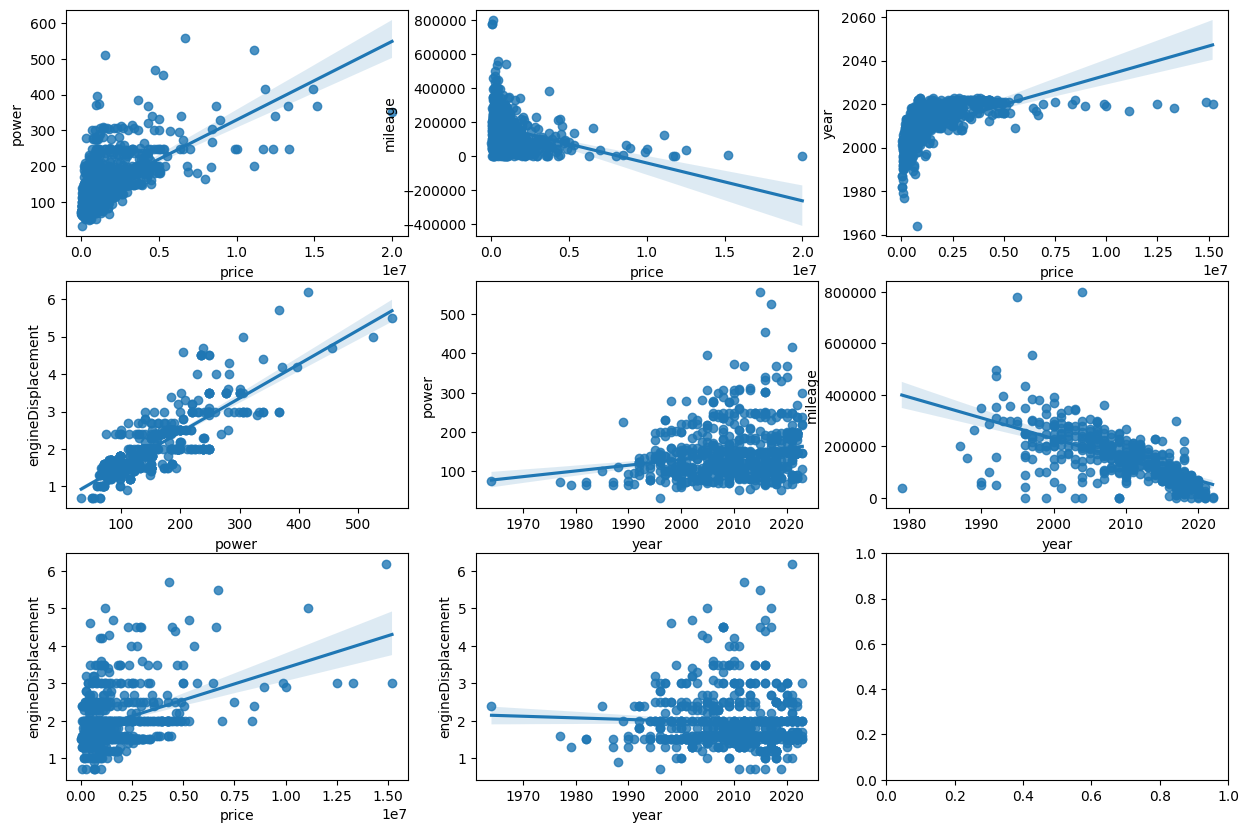

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))

# Заполняем сетку графиками
sns.regplot(data=df, x='price', y='power', ax=axes[0, 0])
sns.regplot(data=df, x='price', y='mileage', ax=axes[0, 1])
sns.regplot(data=df, x='price', y='year', ax=axes[0, 2])
sns.regplot(data=df, x='power', y='engineDisplacement', ax=axes[1, 0])
sns.regplot(data=df, x='year', y='power', ax=axes[1, 1])
sns.regplot(data=df, x='year', y='mileage', ax=axes[1, 2])
sns.regplot(data=df, x='price', y='engineDisplacement', ax=axes[2, 0])
sns.regplot(data=df, x='year', y='engineDisplacement', ax=axes[2, 1])

# Настраиваем внешний вид
# plt.tight_layout()
plt.show()

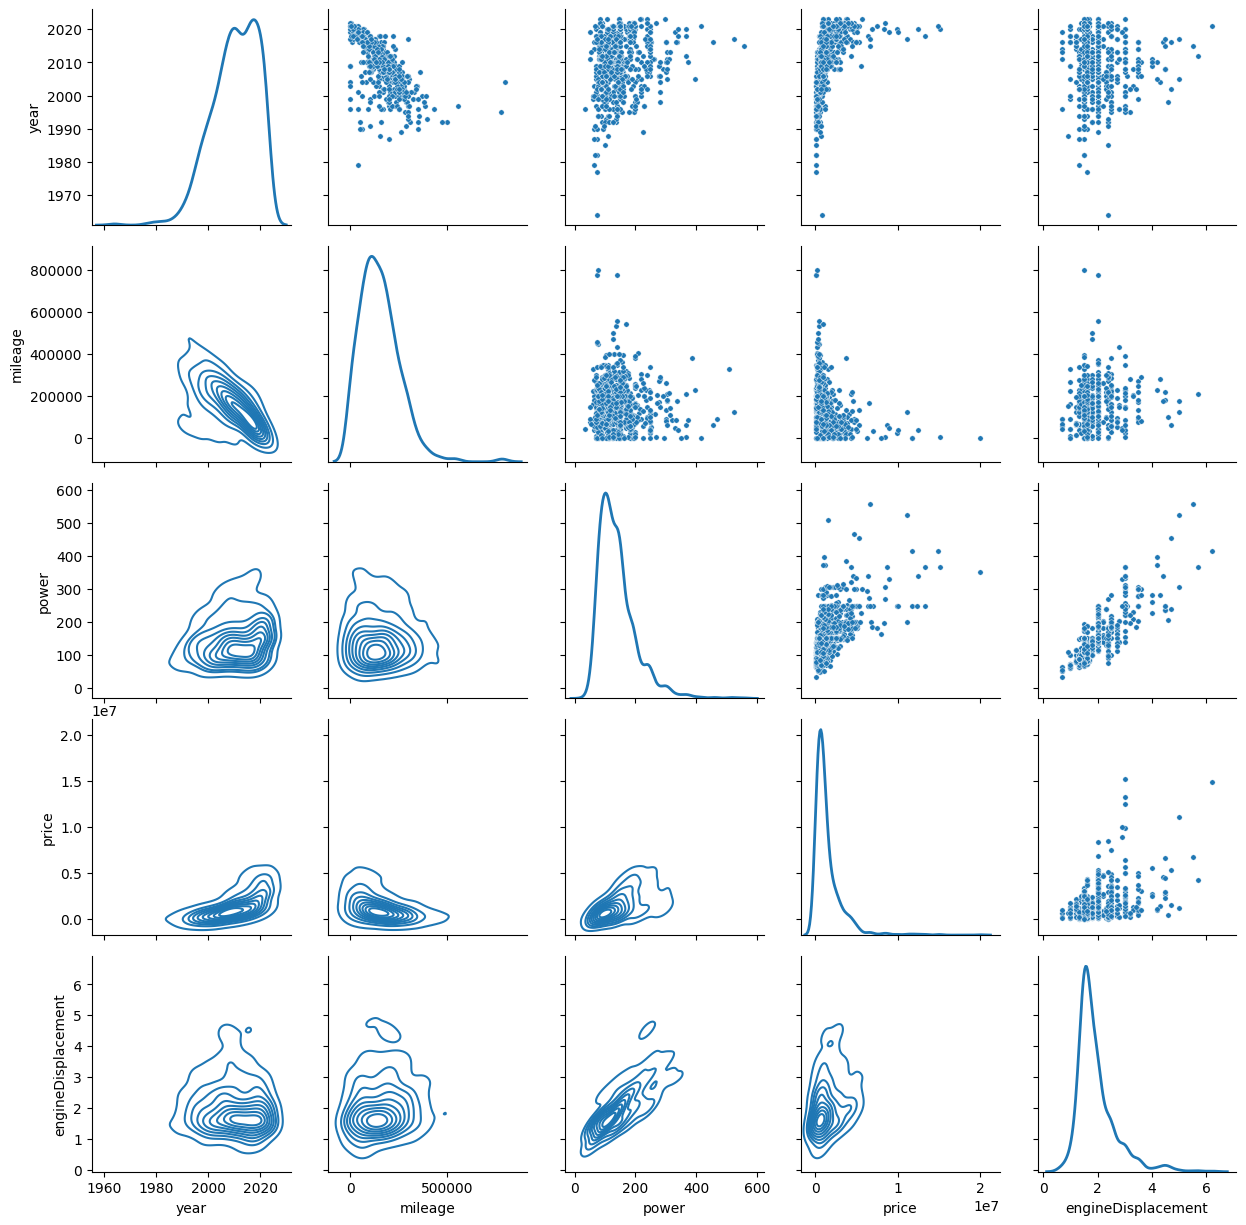

In [9]:
# df = sns.load_dataset("penguins")

g = sns.PairGrid(df, diag_sharey=False)
g.map_upper(sns.scatterplot, s=15)
g.map_lower(sns.kdeplot)
g.map_diag(sns.kdeplot, lw=2)

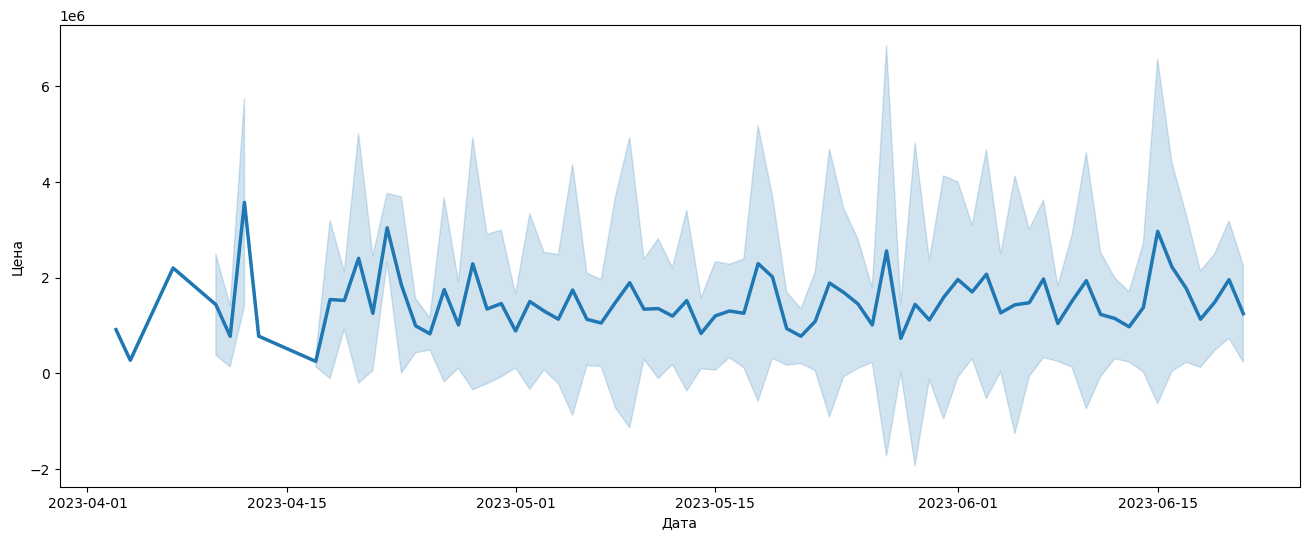

In [10]:
plt.figure(figsize=(16, 6))
sns.lineplot(x='date', y='price', data=df, linewidth=2.5, errorbar='sd')
# sns.lineplot(x='date', y='price', data=df, linewidth=2.5, errorbar=None)
plt.xlabel('Дата') 
plt.ylabel('Цена') 
plt.show()

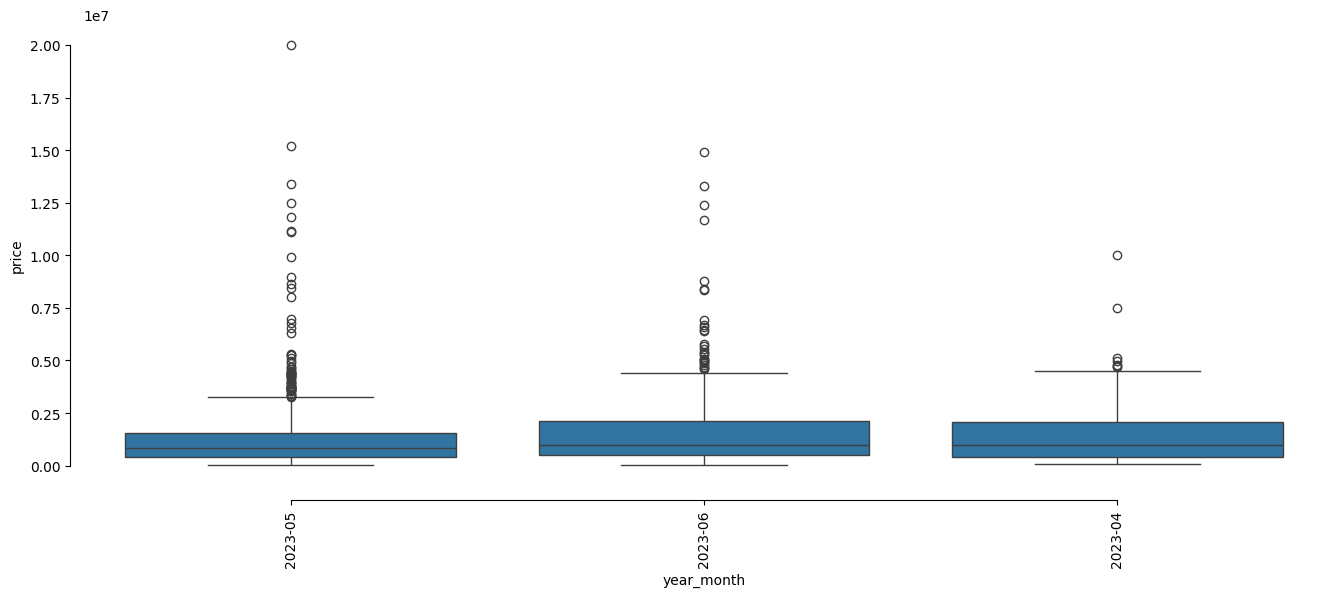

In [11]:
df['year_month'] = df['date'].dt.to_period('M')
df1 = df.sort_values(by='year_month')
plt.figure(figsize=(16, 6))
sns.boxplot(x=df['year_month'], y="price", data=df1)
sns.despine(offset=10, trim=True)
plt.xticks(rotation=90)
plt.show()

### Формируем `ProfileReport` отчет

In [12]:
correlations_config = {
    "pearson": {"calculate": True},
    "spearman": {"calculate": True},
    "kendall": {"calculate": True},
    "phi_k": {"calculate": True},
    "cramers": {"calculate": True}
}
missing_config = {
    "bar": True,      # столбчатая диаграмма
    "matrix": True,   # матрица пропусков
    "heatmap": True, # тепловая карта
    "dendrogram": True # дендрограмма
}
profile = ProfileReport(
    df, 
    missing_diagrams=missing_config, 
    correlations=correlations_config, 
    explorative=True, 
    title='Отчёт по данным')
profile.to_file('отчёт_по_данным.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 17/17 [00:00<00:00, 451.37it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]